In [3]:
import emcee
import numpy as np
import astropy
from astropy.table import QTable, Table, Column
import matplotlib.pyplot as plt
import astropy.visualization.hist
import corner

In [4]:
transient = np.load("transient.npy")

In [5]:
transient

array([[ 0.46954762,  8.83485016,  1.        ],
       [ 1.87898004, 10.90082649,  1.        ],
       [ 2.01075462, 10.46566244,  1.        ],
       [ 2.02183974,  8.46375631,  1.        ],
       [ 3.91877923, 11.48825219,  1.        ],
       [ 6.02254716, 11.89588918,  1.        ],
       [ 6.41474963, 11.17877957,  1.        ],
       [ 7.10360582,  9.82007516,  1.        ],
       [ 8.71292997,  8.92924738,  1.        ],
       [ 9.39405108, 11.05445173,  1.        ],
       [ 9.60984079,  9.59682305,  1.        ],
       [ 9.71012758, 11.22244507,  1.        ],
       [10.20448107, 10.20827498,  1.        ],
       [11.03751412, 10.97663904,  1.        ],
       [11.82744259, 10.3563664 ,  1.        ],
       [11.8727719 , 10.70657317,  1.        ],
       [12.01965612, 10.01050002,  1.        ],
       [12.89262977, 11.78587049,  1.        ],
       [13.17978624, 10.12691209,  1.        ],
       [13.81829513, 10.40198936,  1.        ],
       [14.33532874, 11.8831507 ,  1.   

The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

In [7]:
t_data = transient[:, 0]
flux_data = transient[:,1]
sigma_flux_data = transient[:,2]

Text(0.5, 0, 'time [a. u.]')

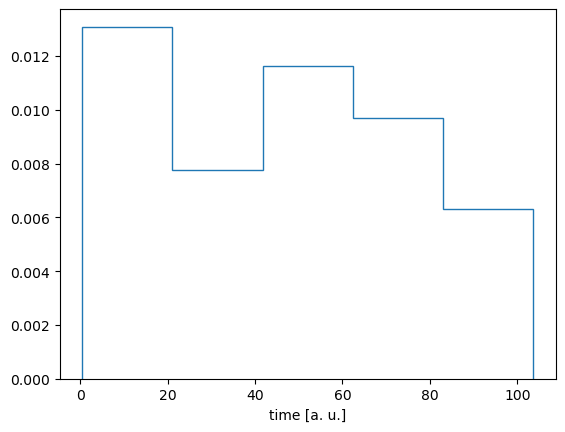

In [8]:
astropy.visualization.hist(t_data, bins="freedman", histtype="step",density=True)
plt.xlabel("time [a. u.]")

Text(0.5, 0, 'flux [a. u.]')

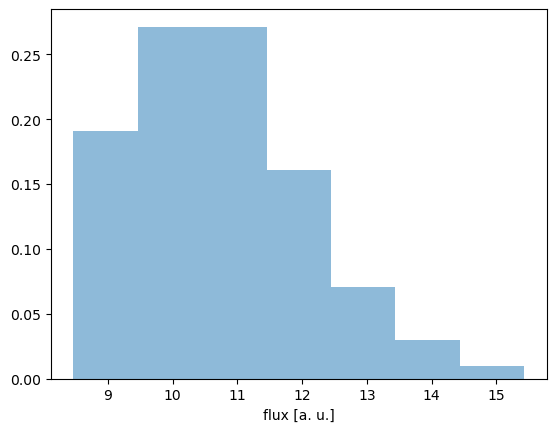

In [9]:
astropy.visualization.hist(flux_data, bins="scott", histtype="bar",density=True, alpha=0.5) #similar to a gaussian 
plt.xlabel("flux [a. u.]")

In [10]:
sigma_flux_data

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

<ErrorbarContainer object of 3 artists>

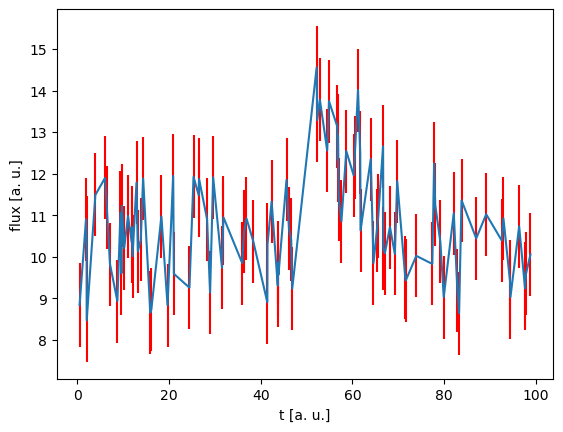

In [11]:
plt.xlabel("t [a. u.]")
plt.ylabel("flux [a. u.]")
plt.errorbar(t_data, flux_data, yerr=sigma_flux_data, xerr=None, ecolor="red")

### model: burst with an exponential tail 

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$ \
where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.


In [14]:
#model to describe data 
#theta rapresents the parameter 
def model(theta,t):
    b, A, alpha, t0 = theta #parameters 
    y = []
    for ti in t:
        if ti < t0:
            y.append(b)
        else:
            y.append(b + A*np.exp(-alpha*(ti-t0)))
    return np.array(y)

#to avoid problem, better to work with log like, log prior and log posterior 
def log_like(theta, sigma_flux, flux, t):
    b, A, alpha, t0 = theta
    analitical_model = model(theta, t)
    return -0.5*np.sum((flux-analitical_model)**2/sigma_flux**2) #chi_square/2

### choose for the prior: 
$$
P(t_0) = \frac{1}{t_{0,max}-t_{0,min}}
$$
$$
P(A) = \frac{1}{A_{max}-A_{min}}
$$
$$
P(b) = \frac{1}{b_{max}-b_{min}}
$$

$$
\log P(\alpha) = -\log \alpha + \text{constant}
$$
the last is because the prior is uniform in $\log(\alpha)$ not in $\alpha$: I need to take into account the factor $\frac{1}{\alpha}$, that doesn't goes to zero when I apply the $\log$. 

In [16]:
#definition of the extreme parameter
t0_min = 0
t0_max = 100
A_min = 0
A_max = 50 
b_min = 0 
b_max = 50 
alpha_min = np.exp(-5)
alpha_max = np.exp(5)

def log_prior(theta): 
    b, A, alpha, t0 = theta
    if (A_min<=A<=A_max) and (b_min<=b<=b_max) and (alpha_min<=alpha<=alpha_max) and (t0_min<=t0<=t0_max): 
        return 0.0 - np.log(alpha)
    else:
        return -np.inf

In [17]:
def log_posterior(theta, sigma_flux, flux, t): 
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    else:
        return lp+log_like(theta, sigma_flux, flux, t)

print(type(log_like))

<class 'function'>


In [18]:
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = 10000  # number of MCMC steps to take **for each walker**

t0_start=50
A_start=8
b_start=10.4
alpha_start= 0.2

theta_start= [b_start, A_start, alpha_start, t0_start]
# initialize theta 
low = np.array([b_min, A_min, alpha_min, t0_min]) #without array tbe operation isn't possible
high = np.array([b_max, A_max, alpha_max, t0_max])
print(high-low) #i what an idea for the scale of the problem 
#starting_guesses = low + (high - low)*1e-1*np.random.rand(nwalkers, ndim) #what is the more precise way to initialize starting guess
#starting_guesses = theta_start+1e-1*np.random.randn(nwalkers, ndim)
# one can try also with eps*(high-low)*np.random.randn(...)
starting_guesses = theta_start+1e-2*np.random.randn(nwalkers, ndim)

[ 50.          50.         148.40642116 100.        ]


In [19]:
test_val = log_posterior([20,25,1,50], sigma_flux_data, flux_data, t_data)
print(test_val)

sampler = emcee.EnsembleSampler(nwalkers,ndim,log_posterior,args=(sigma_flux_data, flux_data, t_data)) #call a function, in args i don't pass theta
sampler.run_mcmc(starting_guesses, nsteps)

-4426.319023855704


State([[10.20738162  7.38665526  0.14567044 48.06230791]
 [10.39759486  4.63344871  0.14225588 51.06366015]
 [10.40850498  6.53623975  0.13525508 48.43197784]
 [10.38553414  8.41679177  0.17151332 47.30641342]
 [10.27288394  5.65866642  0.15458398 50.53870334]
 [10.03281656  6.22977623  0.14224038 50.58265249]
 [10.16909059  5.29634918  0.11002509 49.70372096]
 [10.26311102  3.91220675  0.13675351 51.96719827]
 [10.22082987  5.66876183  0.15184218 49.35277071]
 [10.36264733  5.94453586  0.11815385 47.64937258]
 [10.28737405  6.76849685  0.14875001 48.19905665]
 [10.41283066  3.66006223  0.07848017 49.88959349]
 [10.43824513  4.97789231  0.12488367 50.031467  ]
 [10.21752579  7.51656057  0.1326167  47.72196153]
 [10.37045712  6.26526147  0.12890377 49.05702292]
 [10.28454891  3.66346232  0.11695779 51.21627503]
 [10.30030763  6.94903034  0.14024068 47.81074568]
 [10.1424593   5.24875695  0.11236953 50.2577257 ]
 [10.46354276  7.89742548  0.13523991 46.96517481]
 [10.43705916  6.07496374

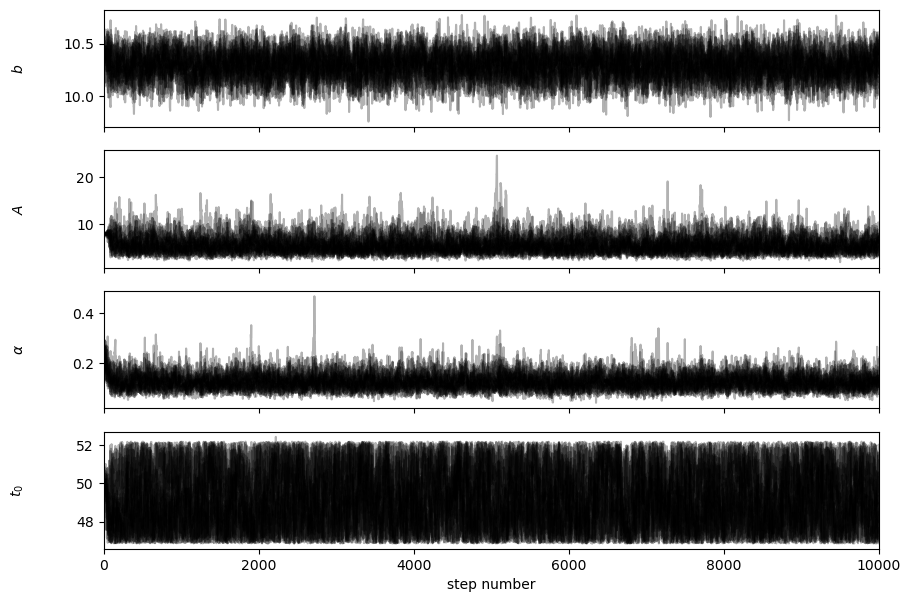

In [20]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = [r"$b$", r"$A$", r"$\alpha$", r"$t_0$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [68]:
tau = sampler.get_autocorr_time() #how many time do I take to have a sample that is independent from the previous one 
print(tau)
#burnin = int(2 * np.max(tau)) #or maybe three, in general watch the parameter you have  

[56.69140314 78.0085371  60.36022313 79.18702715]


In [70]:
flat_samples = sampler.get_chain(discard=200, thin=int(max(tau)), flat=True) 
print(flat_samples.shape)

(2480, 4)


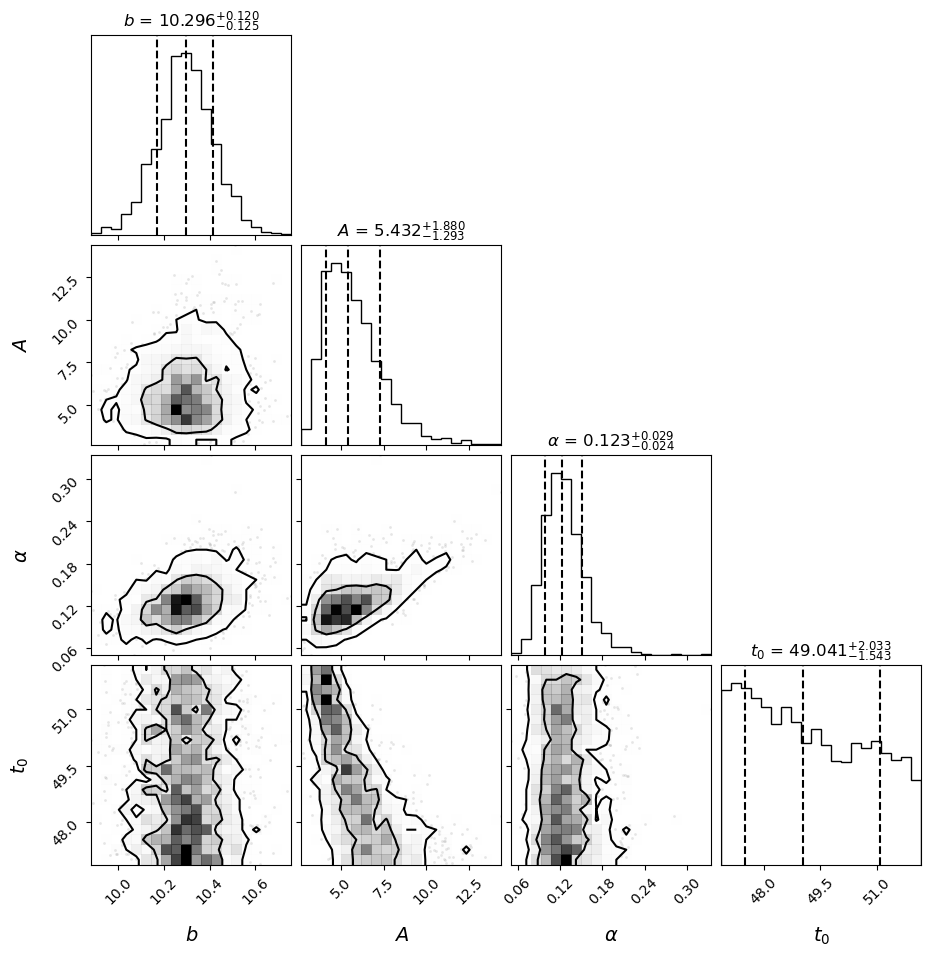

In [72]:
#what is the precision I estimate quantile
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95], #credible level
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

In [74]:
print(flat_samples)

[[10.36424943  5.27935124  0.09331786 47.65289282]
 [10.15789906  5.97604079  0.13719641 49.09418567]
 [10.18296314  3.78348738  0.1021933  51.65429621]
 ...
 [10.15548842  5.9754097   0.12180818 49.4385323 ]
 [10.40101959  6.9208428   0.12245916 46.93209915]
 [10.53408545  6.03432489  0.12004693 47.15457261]]


In [76]:
sample_from_model = np.random.choice(len(flat_samples), size=100)
samples_100 = flat_samples[sample_from_model]

In [78]:
print(samples_100)

[[10.22307978  4.25215357  0.14958285 52.17787441]
 [10.22534125  5.21744645  0.13653795 50.45915337]
 [10.35860055  9.14575902  0.15547692 46.94745905]
 [10.3642076   5.58789117  0.15172236 50.10123664]
 [10.26654712  2.90198956  0.08435474 52.08788339]
 [10.29974324  4.59508944  0.12443639 49.64486379]
 [10.13964528  4.18544856  0.08605616 51.77836913]
 [10.53579219  5.1862039   0.19442787 50.76445766]
 [10.36070315  5.43189993  0.12331906 48.91813811]
 [10.21969297  6.34747277  0.13145293 49.21220202]
 [10.24629725  3.52781285  0.09150367 52.06927791]
 [10.25442001  4.78186632  0.09178496 49.72497471]
 [10.18647635  5.79430692  0.12051131 48.34063235]
 [10.31184858  7.87774504  0.13964222 47.25541986]
 [10.3561026   6.38024457  0.18208348 49.30573526]
 [10.31499183  3.86909981  0.0983889  50.77126434]
 [10.51179945 14.38365523  0.28144755 48.16059189]
 [10.2850071   7.77359011  0.15459464 47.55308248]
 [10.0092207   5.16473838  0.0865488  47.95598343]
 [10.51179945 14.38365523  0.28

Text(0, 0.5, 'flux [a. u.]')

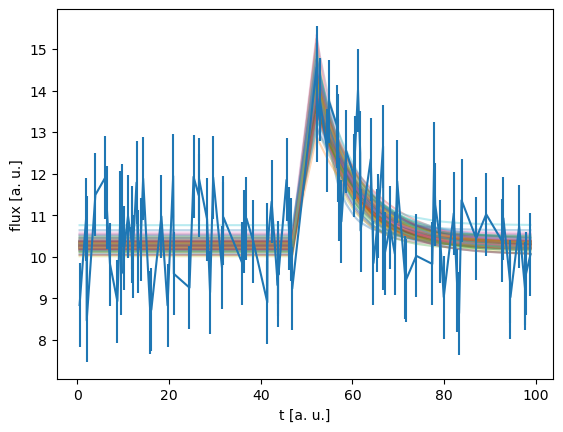

In [80]:
for s in samples_100:
    y = model(s, t_data)
    plt.plot(t_data, y, alpha =0.3)

plt.errorbar(t_data, flux_data, yerr=sigma_flux_data, xerr=None)
plt.xlabel("t [a. u.]")
plt.ylabel("flux [a. u.]")

In [82]:
#end statistic
#labels = [r"$b$", r"$A$", r"$\alpha$", r"$t_0$"]
b_samples = flat_samples[:,0] 
A_samples = flat_samples[:,1]
alpha_samples =  flat_samples[:,2]
t_0_samples = flat_samples[:,3]

b_samples_median = np.median(b_samples)
A_samples_median = np.median(A_samples)
alpha_samples_median = np.median(alpha_samples)
t_0_samples_median = np.median(t_0_samples)

In [84]:
print(b_samples_median)
print(A_samples_median)
print(alpha_samples_median)
print(t_0_samples_median)

10.295846943550334
5.432299010660503
0.12328852855156347
49.04052219332006


In [86]:
#find 90% credible region
p_5_b = np.percentile(flat_samples[:,0],5)
p_95_b = np.percentile(flat_samples[:,0] , 95) 

p_5_A = np.percentile(flat_samples[:,1],5)
p_95_A = np.percentile(flat_samples[:,1] , 95) 

p_5_alpha = np.percentile(flat_samples[:,2],5)
p_95_alpha = np.percentile(flat_samples[:,2] , 95) 

p_5_t0 = np.percentile(flat_samples[:,3],5)
p_95_t0 = np.percentile(flat_samples[:,3] , 95) 

In [88]:
print([p_5_b, b_samples_median, p_95_b])
print([p_5_A, A_samples_median, p_95_A])
print([p_5_alpha, alpha_samples_median, p_95_alpha])
print([p_5_t0, t_0_samples_median, p_95_t0])

[10.088771972026235, 10.295846943550334, 10.50007026600191]
[3.643394904549184, 5.432299010660503, 8.886560449859257]
[0.08626647131377227, 0.12328852855156347, 0.17659787826940382]
[47.082699346697325, 49.04052219332006, 51.79192581483082]


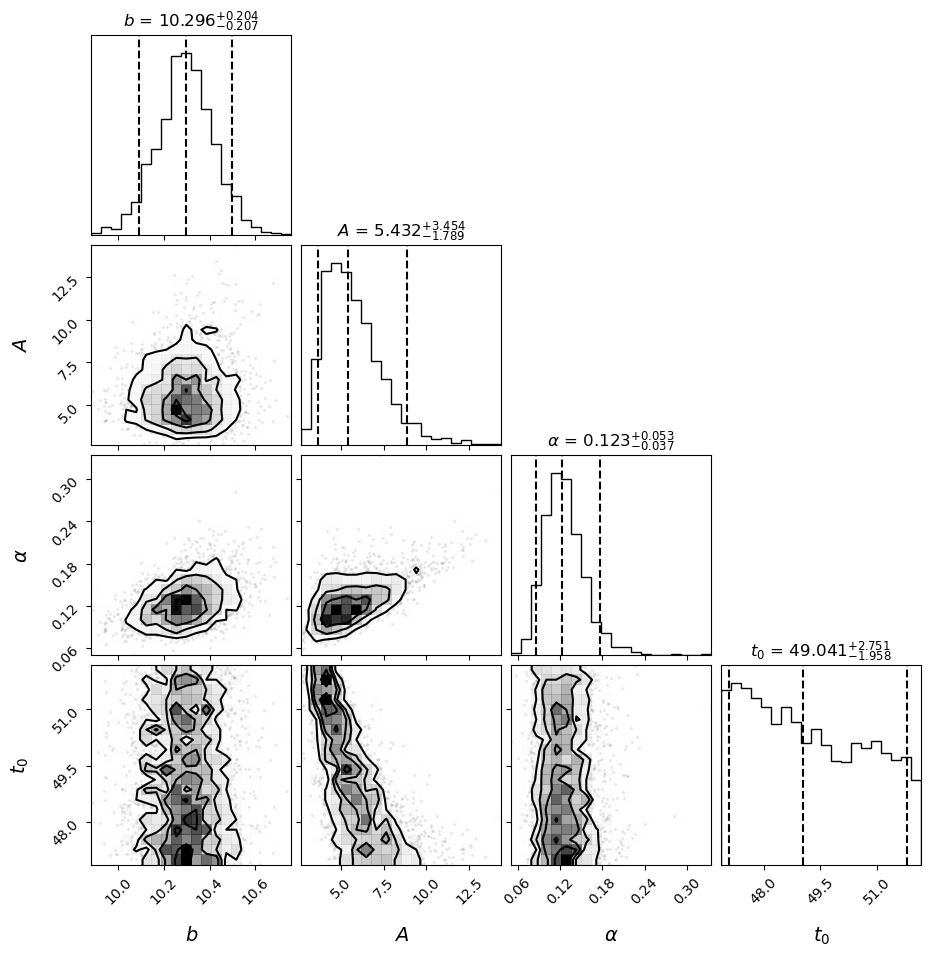

In [90]:
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.05, 0.5, 0.95], #the same as taking the percentile and the median
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)